### Author: B282025<br>
### MSc Bioinformatics Dissertation<br>
### August 2026<br>

Description: This notebook generates plots to analyse whether collagen (Col1 and Col3) intensity is greater in Fibronectin niches compared to non-niche tubulointerstitial tissue.<br>

A Wilcoxon t-test is used to test for a significant change in collagen.<br>

Reference: This code was written using a combination of manual scripting and Claude Sonnet 5.


In [20]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import matplotlib as mpl

In [21]:
# ---------------------------------------------------------------------
# Shared plot styling (kept identical across all analysis notebooks)
# ---------------------------------------------------------------------

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.title_fontsize": 11,
    "savefig.bbox": "tight",
})

In [22]:
# READ IN DATA
df = pd.read_csv('../Akoya_Data/Aim1_Project/measurements/col_in_niche_non_niche.tsv', sep='\t')

In [23]:
df

,Image,Object ID,Object type,Name,Classification,Parent,ROI,Centroid X µm,Centroid Y µm,Area µm^2,Perimeter µm,Num Detections,Num Fibronectin,ANNOTATION_DESCRIPTION,ROI: 2.00 µm per pixel: Col1: Mean,ROI: 2.00 µm per pixel: Col3: Mean
0,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,94ca4c17-5d7b-43f8-ad24-013306410072,Annotation,ObK,NaN,Root object (Image),Polygon,8755.8,12834.00,91195495.2,46004.8,239798,20400,ObK_1,NaN,NaN
1,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,3755a5e3-7e85-4e42-ae5c-b7ebbe072775,Annotation,ObK_1,Tissue,ObK,Geometry,6268.6,13462.60,40731644.1,207605.1,239650,20353,NaN,NaN,NaN
2,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,bc35bbb7-9db1-4ab6-8862-8782b80569c5,Annotation,ObK_1,Fibronectin,Annotation (Tissue),Geometry,5807.0,13161.40,9587616.1,150220.7,68570,11804,NaN,17.1100,7.1069
3,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,14b6ce37-7b49-451f-87d6-dc4da2a17b18,Annotation,ObK_1,Ignore*,Annotation (Tissue),Geometry,6410.6,13555.30,31144028.1,233184.5,171080,8549,NaN,16.7000,7.6113
4,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,e4aba38f-8460-4ce8-839d-9d94fd89f082,Annotation,Non-ObK,NaN,Root object (Image),Polygon,9581.1,5330.90,52971811.2,32475.2,162624,11230,NonObK_2,NaN,NaN
5,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,4a9a98a3-b548-4818-9c8e-21b757601294,Annotation,ObK,NaN,Root object (Image),Polygon,11633.8,28792.60,40383646.0,25321.9,128413,3391,ObK_4,NaN,NaN
6,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,58be0888-b3ca-4f91-9517-5d97aa0aa642,Annotation,ObK_4,Tissue,ObK,Geometry,10710.5,29109.50,15581396.1,61910.0,128359,3383,NaN,NaN,NaN
7,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,2a53fc08-3fe8-4a0a-9c83-1e9a5b3d0f10,Annotation,ObK_4,Fibronectin,Annotation (Tissue),Geometry,11816.6,28561.90,883558.4,19360.0,9108,877,NaN,11.1921,4.6047
8,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,6589de41-a826-499b-b5ca-390c5edc28d6,Annotation,ObK_4,Ignore*,Annotation (Tissue),Geometry,10644.0,29142.40,14697837.8,76672.1,119251,2506,NaN,10.7657,4.8404
9,PPJ_07_2_Scan1_DB_fn_heatmap_col.qptiff,5814503b-8d43-4e94-89ab-799bb878820e,Annotation,ObK,NaN,Root object (Image),Polygon,3043.5,27866.30,37889738.1,29160.6,174556,8141,ObK_3,NaN,NaN


### Subset just the Non-Niche "Ignore*" and Fibronectin Annotations

In [24]:
sub = df[df["Classification"].isin(["Ignore*", "Fibronectin"])].copy()
sub["Section"] = sub["Name"]
sub["Category"] = sub["Section"].apply(lambda s: "ObK" if s.startswith("ObK") else "Non-ObK")

sub[["Section", "Category", "Classification"]].reset_index(drop=True)

,Section,Category,Classification
0,ObK_1,ObK,Fibronectin
1,ObK_1,ObK,Ignore*
2,ObK_4,ObK,Fibronectin
3,ObK_4,ObK,Ignore*
4,ObK_3,ObK,Ignore*
5,ObK_3,ObK,Fibronectin
6,NonObK_3,Non-ObK,Ignore*
7,NonObK_3,Non-ObK,Fibronectin
8,ObK_2,ObK,Fibronectin
9,ObK_2,ObK,Ignore*


### Collagen in Fibronectin Niches vs Whole Tubulointerstitial Tissue

Each tissue section has a paired measurement: its whole-tissue collagen intensity and, where a niche was annotated, its Fibronectin-niche intensity. One tissue section (ObK_5) has no Fibronectin niche annotated, so it's excluded from the paired comparison.

Because this is paired, within-section data (not independent samples), the figure below draws one line per tissue section connecting its Tissue value to its Fibronectin Niche value, colored by category (ObK vs Non-ObK). A paired Wilcoxon signed-rank test (pooling across category, since n is small — 4 ObK + 3 Non-ObK) is annotated on each panel.


In [25]:
CATEGORY_COLORS = {
    "ObK": "#D0841A",
    "Non-ObK": "#3A6691",
}


def _get_category_color(category):
    color = CATEGORY_COLORS.get(category)
    return color

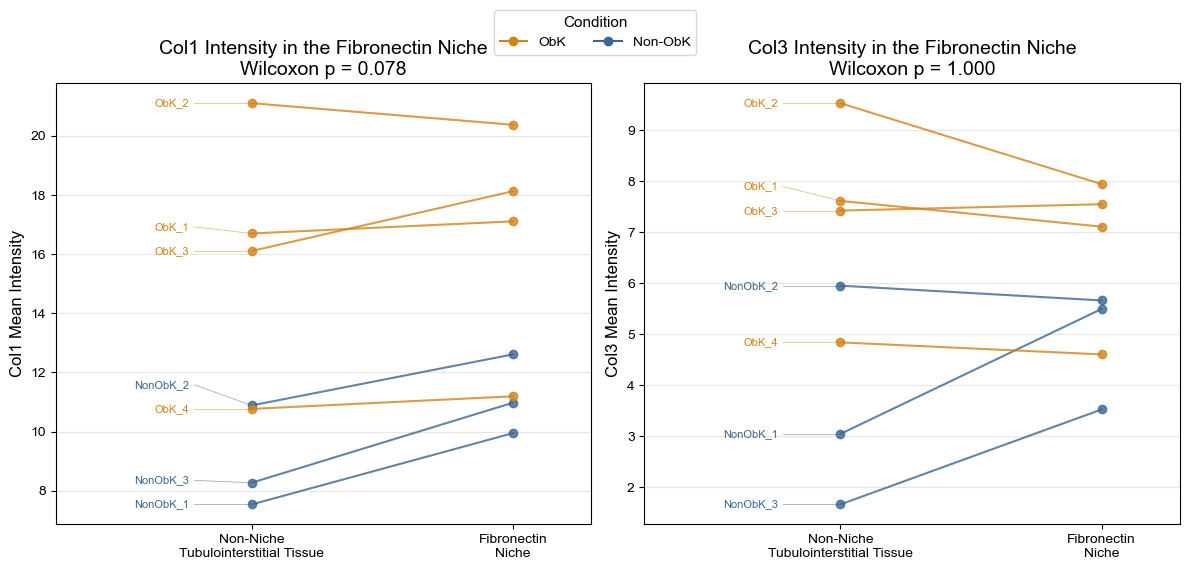

In [26]:
def declutter(ys, min_gap):
    """Nudge apart y-positions that are closer than min_gap, preserving order,
    so line labels don't overlap when values are close together."""
    order = sorted(range(len(ys)), key=lambda i: ys[i])
    ys_sorted = [ys[i] for i in order]
    for i in range(1, len(ys_sorted)):
        if ys_sorted[i] - ys_sorted[i - 1] < min_gap:
            ys_sorted[i] = ys_sorted[i - 1] + min_gap
    new_ys = [0.0] * len(ys)
    for idx, orig_i in enumerate(order):
        new_ys[orig_i] = ys_sorted[idx]
    return new_ys


markers = {
    "Col1": "ROI: 2.00 µm per pixel: Col1: Mean",
    "Col3": "ROI: 2.00 µm per pixel: Col3: Mean",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, (marker_name, col) in zip(axes, markers.items()):
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", alpha=0.3)

    wide = sub.pivot(index="Section", columns="Classification", values=col)
    cat_map = sub.drop_duplicates("Section").set_index("Section")["Category"]
    wide = wide.dropna(subset=["Ignore*", "Fibronectin"])  # drop sections missing a pair
    wide["Category"] = cat_map

    # de-clutter section labels so close-together values don't overlap
    y_range = wide["Ignore*"].max() - wide["Ignore*"].min()
    min_gap = max(y_range * 0.06, 0.3)
    label_ys = declutter(list(wide["Ignore*"]), min_gap)

    for (section, row), label_y in zip(wide.iterrows(), label_ys):
        color = _get_category_color(row["Category"])
        ax.plot(
            [0, 1], [row["Ignore*"], row["Fibronectin"]],
            marker="o", color=color, alpha=0.8, zorder=2
        )
        # thin leader line from the label to its actual Tissue point
        ax.plot([-0.22, 0], [label_y, row["Ignore*"]], color=color, lw=0.6, alpha=0.5, zorder=1)
        ax.annotate(section, xy=(-0.24, label_y), ha="right", va="center", fontsize=8, color=color)

    stat, p = wilcoxon(wide["Ignore*"], wide["Fibronectin"])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Non-Niche\nTubulointerstitial Tissue", "Fibronectin\nNiche"])
    ax.set_ylabel(f"{marker_name} Mean Intensity")
    ax.set_title(f"{marker_name} Intensity in the Fibronectin Niche\nWilcoxon p = {p:.3f}")
    ax.set_xlim(-0.75, 1.3)

handles = [
    plt.Line2D([0], [0], color=_get_category_color(cat), marker="o", label=cat)
    for cat in CATEGORY_COLORS
]
fig.legend(handles=handles, title="Condition", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout()

fig.savefig("collagen_in_FN_niches2.png", dpi=300, bbox_inches="tight")
plt.show()